<a href="https://colab.research.google.com/github/mateoveega/MCMC-MonteCarlo-TFG/blob/main/CH_3/banana.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import os
import sys
import importlib

repo_name = 'MCMC-MonteCarlo-TFG'
repo_url = f'https://github.com/mateoveega/{repo_name}.git'
repo_path = f'/content/{repo_name}'

if not os.path.exists(repo_path):
    !git clone {repo_url}
else:
    %cd {repo_path}
    !git pull
    %cd /content

if repo_path not in sys.path:
    sys.path.append(repo_path)

import aux
importlib.reload(aux)
from aux import log_banana
import samplers
importlib.reload(samplers)
from samplers import box_muller, random_walk_metropolis

from google.colab import files
import numpy as np
import matplotlib.pyplot as plt



/content/MCMC-MonteCarlo-TFG
Already up to date.
/content


In [18]:
d = 2
num_iterations = 20000
t0 = 500
c = 0.4
sd = c * ((2.38**2) / d)
epsilon = 1e-5

seed_box = 1
seed_unif = 2

Z_samples = box_muller(D=d, num_samples=num_iterations, seed=seed_box)

rng_unif = np.random.default_rng(seed_unif)
U_samples = rng_unif.random(num_iterations)

samples = np.zeros((num_iterations, d))
samples[0] = np.array([0.0, 0.0])

cov_t = np.eye(d) * 0.1
cov_empirical = np.zeros((d, d))
mean_t = samples[0].copy()

accepted = 0

for t in range(1, num_iterations):
    x_prev = samples[t-1]

    if t > t0:
        diff = x_prev - mean_t
        mean_t = mean_t + diff / t
        cov_empirical = ((t - 1) / t) * cov_empirical + (1 / t) * np.outer(diff, x_prev - mean_t)
        cov_t = sd * cov_empirical + sd * epsilon * np.eye(d)

    L = np.linalg.cholesky(cov_t)
    y_cand = x_prev + L @ Z_samples[t]

    log_alpha = log_banana(y_cand) - log_banana(x_prev)

    if np.log(U_samples[t]) < log_alpha:
        samples[t] = y_cand
        accepted += 1
    else:
        samples[t] = x_prev

print(f"Tasa de aceptacion AM: {accepted / num_iterations:.4f}")

Tasa de aceptacion AM: 0.2687


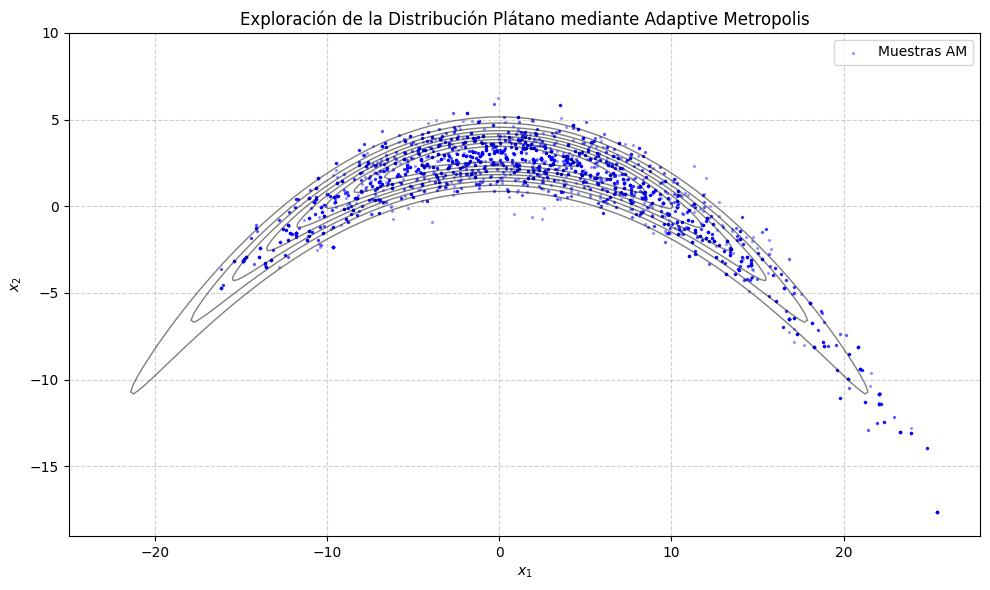

In [42]:
burn_in = 1000
valid_samples = samples[burn_in:]

num_plot_steps = 5000
fin_plot = burn_in + num_plot_steps

x_grid = np.linspace(-25, 25, 200)
y_grid = np.linspace(-15, 10, 200)
X, Y = np.meshgrid(x_grid, y_grid)
Z = np.zeros_like(X)
for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        Z[i, j] = np.exp(log_banana([X[i, j], Y[i, j]])) # Densidad real

plt.figure(figsize=(10, 6))

plt.contour(X, Y, Z, levels=10, colors='black', alpha=0.5, linewidths=1)

plt.scatter(valid_samples[burn_in:fin_plot, 0], valid_samples[burn_in:fin_plot, 1], s=2, alpha=0.3, color='blue', label='Muestras AM')

plt.title('Exploración de la Distribución Plátano mediante Adaptive Metropolis')
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('BANANA.pdf')
plt.show()

In [39]:
num_iterations = 20000
initial_position = [0.0, 0.0]
def pdf_banana(x):
    """Envoltura para obtener p(x) real, necesaria para la función RWM original."""
    return np.exp(log_banana(x))

sigma_corta = 0.5
muestras_corta, acc_corta = random_walk_metropolis(
    pdf_banana, num_iterations, initial_position, sigma_corta, seed=200
)

sigma_media = 4.0
muestras_media, acc_media = random_walk_metropolis(
    pdf_banana, num_iterations, initial_position, sigma_media, seed=300
)

sigma_larga = 7.0
muestras_larga, acc_larga = random_walk_metropolis(
    pdf_banana, num_iterations, initial_position, sigma_larga, seed=300
)

print(f"RWM Isotrópico (sigma={sigma_corta}): Tasa de aceptación = {acc_corta:.4f}")
print(f"RWM Isotrópico (sigma={sigma_media}): Tasa de aceptación = {acc_media:.4f}")
print(f"RWM Isotrópico (sigma={sigma_larga}): Tasa de aceptación = {acc_larga:.4f}")

RWM Isotrópico (sigma=0.5): Tasa de aceptación = 0.8265
RWM Isotrópico (sigma=4.0): Tasa de aceptación = 0.2589
RWM Isotrópico (sigma=7.0): Tasa de aceptación = 0.1492


<>:18: SyntaxWarning: invalid escape sequence '\s'
<>:27: SyntaxWarning: invalid escape sequence '\s'
<>:28: SyntaxWarning: invalid escape sequence '\s'
<>:36: SyntaxWarning: invalid escape sequence '\s'
<>:37: SyntaxWarning: invalid escape sequence '\s'
<>:18: SyntaxWarning: invalid escape sequence '\s'
<>:27: SyntaxWarning: invalid escape sequence '\s'
<>:28: SyntaxWarning: invalid escape sequence '\s'
<>:36: SyntaxWarning: invalid escape sequence '\s'
<>:37: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_4439/2205091635.py:18: SyntaxWarning: invalid escape sequence '\s'
  s=2, alpha=0.3, color='red', label=f'RWM $\sigma={sigma_corta}$')
/tmp/ipykernel_4439/2205091635.py:27: SyntaxWarning: invalid escape sequence '\s'
  s=2, alpha=0.3, color='orange', label=f'RWM $\sigma={sigma_media}$')
/tmp/ipykernel_4439/2205091635.py:28: SyntaxWarning: invalid escape sequence '\s'
  axes[1].set_title(f'Calibración Manual Óptima ($\sigma={sigma_media}$) - Acc: {acc_media*100:.1f}%')
/t

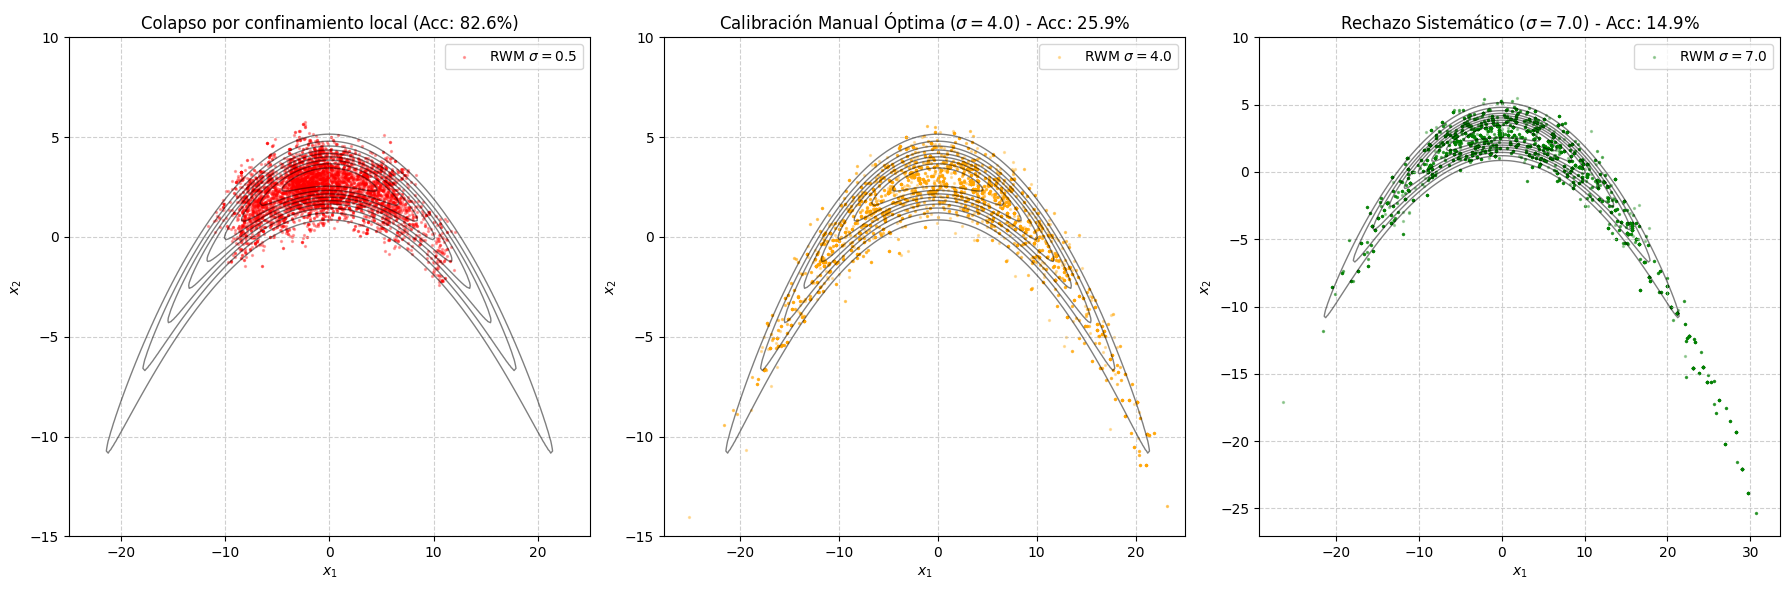

In [44]:
burn_in = 1000

x_grid = np.linspace(-25, 25, 200)
y_grid = np.linspace(-15, 10, 200)
X, Y = np.meshgrid(x_grid, y_grid)
Z = np.zeros_like(X)
for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        Z[i, j] = np.exp(log_banana([X[i, j], Y[i, j]]))

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

num_plot_steps = 5000
fin_plot = burn_in + num_plot_steps

axes[0].contour(X, Y, Z, levels=10, colors='black', alpha=0.5, linewidths=1)
axes[0].scatter(muestras_corta[burn_in:fin_plot, 0], muestras_corta[burn_in:fin_plot, 1],
                s=2, alpha=0.3, color='red', label=f'RWM $\sigma={sigma_corta}$')
axes[0].set_title(f'Colapso por confinamiento local (Acc: {acc_corta*100:.1f}%)')
axes[0].set_xlabel('$x_1$')
axes[0].set_ylabel('$x_2$')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.6)

axes[1].contour(X, Y, Z, levels=10, colors='black', alpha=0.5, linewidths=1)
axes[1].scatter(muestras_media[burn_in:fin_plot, 0], muestras_media[burn_in:fin_plot, 1],
                s=2, alpha=0.3, color='orange', label=f'RWM $\sigma={sigma_media}$')
axes[1].set_title(f'Calibración Manual Óptima ($\sigma={sigma_media}$) - Acc: {acc_media*100:.1f}%')
axes[1].set_xlabel('$x_1$')
axes[1].set_ylabel('$x_2$')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.6)

axes[2].contour(X, Y, Z, levels=10, colors='black', alpha=0.5, linewidths=1)
axes[2].scatter(muestras_larga[burn_in:fin_plot, 0], muestras_larga[burn_in:fin_plot, 1],
                s=2, alpha=0.3, color='green', label=f'RWM $\sigma={sigma_larga}$')
axes[2].set_title(f'Rechazo Sistemático ($\sigma={sigma_larga}$) - Acc: {acc_larga*100:.1f}%')
axes[2].set_xlabel('$x_1$')
axes[2].set_ylabel('$x_2$')
axes[2].legend()
axes[2].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('BANANA_rwm.pdf')
plt.show()

In [45]:
from google.colab import files

files.download("BANANA.pdf")
files.download("BANANA_rwm.pdf")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>